In [20]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/climate-change-earth-surface-temperature-data/GlobalTemperatures.csv
/kaggle/input/climate-change-earth-surface-temperature-data/GlobalLandTemperaturesByState.csv
/kaggle/input/climate-change-earth-surface-temperature-data/GlobalLandTemperaturesByCountry.csv
/kaggle/input/climate-change-earth-surface-temperature-data/GlobalLandTemperaturesByCity.csv
/kaggle/input/climate-change-earth-surface-temperature-data/GlobalLandTemperaturesByMajorCity.csv


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


           dt  AverageTemperature  AverageTemperatureUncertainty   City  \
0  1743-11-01               6.068                          1.737  Århus   
1  1743-12-01                 NaN                            NaN  Århus   
2  1744-01-01                 NaN                            NaN  Århus   
3  1744-02-01                 NaN                            NaN  Århus   
4  1744-03-01                 NaN                            NaN  Århus   

   Country Latitude Longitude  
0  Denmark   57.05N    10.33E  
1  Denmark   57.05N    10.33E  
2  Denmark   57.05N    10.33E  
3  Denmark   57.05N    10.33E  
4  Denmark   57.05N    10.33E  
(8235082, 8)
dt                               0
AverageTemperature               0
AverageTemperatureUncertainty    0
City                             0
Country                          0
Latitude                         0
Longitude                        0
Year                             0
dtype: int64


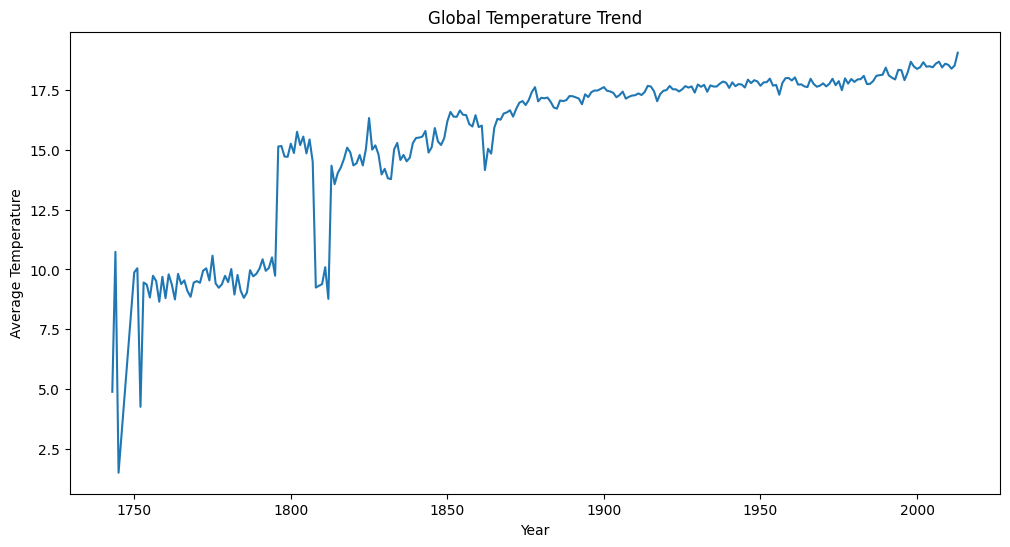

In [21]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv(
    '/kaggle/input/climate-change-earth-surface-temperature-data/GlobalLandTemperaturesByCity.csv'
)


print(df.head())


df = df.dropna()


df['dt'] = pd.to_datetime(df['dt'])


df['Year'] = df['dt'].dt.year


print(df.shape)
print(df.isnull().sum())


yearly_temp = df.groupby('Year')['AverageTemperature'].mean()


plt.figure(figsize=(12,6))
plt.plot(yearly_temp)

plt.title("Global Temperature Trend")
plt.xlabel("Year")
plt.ylabel("Average Temperature")

plt.show()



In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

yearly_temp = df.groupby('Year')['AverageTemperature'].mean().reset_index()

X = yearly_temp[['Year']]
y = yearly_temp['AverageTemperature']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))



R2 Score: 0.8153539955167961


In [23]:
future_years = pd.DataFrame({
    'Year': [2030, 2040, 2050]
})

predictions = model.predict(future_years)

for year, temp in zip(future_years['Year'], predictions):
    print(f"{year}: {temp:.2f} °C")

2030: 20.95 °C
2040: 21.33 °C
2050: 21.70 °C


In [25]:
print("Disaster Risk Prediction")
print("------------------------")

for year, temp in zip(
    future_years['Year'],
    predictions
):

    if temp > 21:
        risk = "High Heatwave Risk"

    elif temp > 20:
        risk = "Moderate Climate Risk"

    else:
        risk = "Low Risk"

    print(f"{year} --> {risk}")

Disaster Risk Prediction
------------------------
2030 --> Moderate Climate Risk
2040 --> High Heatwave Risk
2050 --> High Heatwave Risk


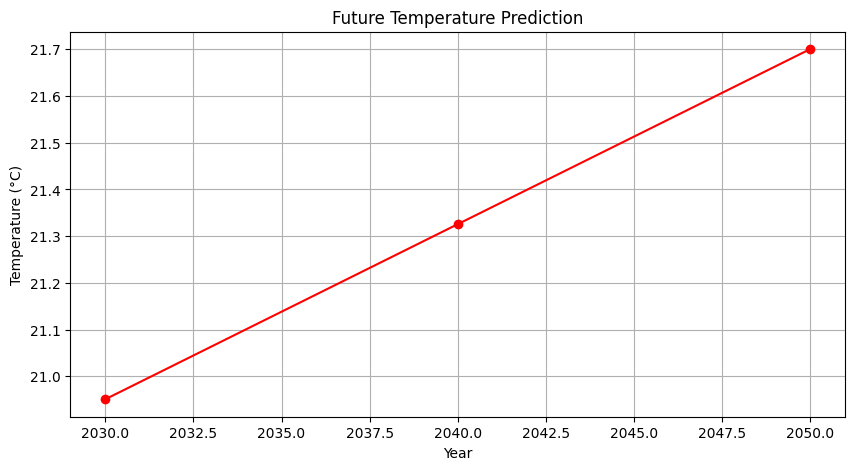

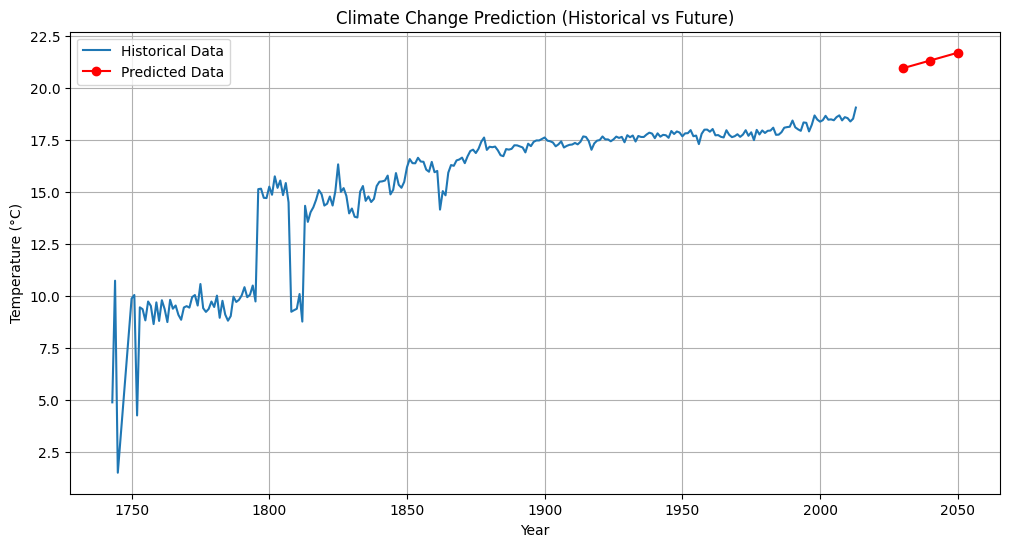

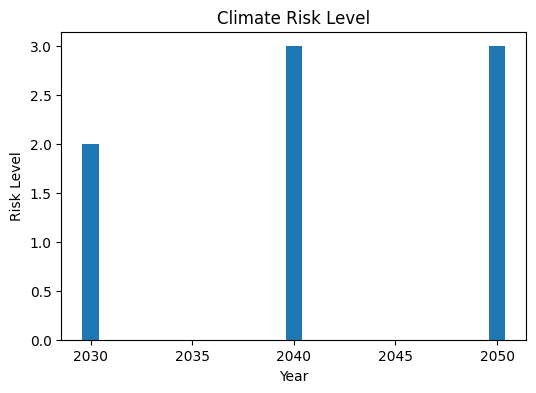

In [28]:
plt.figure(figsize=(10,5))
plt.plot(future_years['Year'], predictions, marker='o', color='red')

plt.title("Future Temperature Prediction")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()
plt.figure(figsize=(12,6))

# historical
plt.plot(yearly_temp['Year'], yearly_temp['AverageTemperature'], label="Historical Data")

# future
plt.plot(future_years['Year'], predictions, marker='o', label="Predicted Data", color='red')

plt.title("Climate Change Prediction (Historical vs Future)")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)

plt.show()
risk_values = []

for temp in predictions:
    if temp > 21:
        risk_values.append(3)
    elif temp > 20:
        risk_values.append(2)
    else:
        risk_values.append(1)

plt.figure(figsize=(6,4))
plt.bar(future_years['Year'], risk_values)

plt.title("Climate Risk Level")
plt.xlabel("Year")
plt.ylabel("Risk Level")
plt.show()